<a href="https://colab.research.google.com/github/soonhyeong/NVIDIA_AI_Edu/blob/main/010_project5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#numpy

In [2]:
!pip install -q koreanize-matplotlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
plt.rcParams['axes.unicode_minus'] = False
print("준비 완료")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 90.5 MB/s eta 0:00:00
준비 완료


In [ ]:
import numpy as np

a = ['1', '2', '3', '4']

b = np.array(a)                 # 리스트 a를 배열로 생성
c = np.array(a, dtype = int)   # 리스트 a를 정수형 배열로 생성

print(b)
print(c)

['1' '2' '3' '4']
[1 2 3 4]


In [ ]:
import random
import numpy as np

number = []

for _ in range(5):
  x = random.randint(1, 100)
  number.append(x)

print(number)


n = np.random.randint(1, 7, 10) # 1 ~ 6 의 값을 10개 선정

print(n)



[39, 87, 50, 78, 69]
[5 6 6 3 6 1 6 6 1 3]


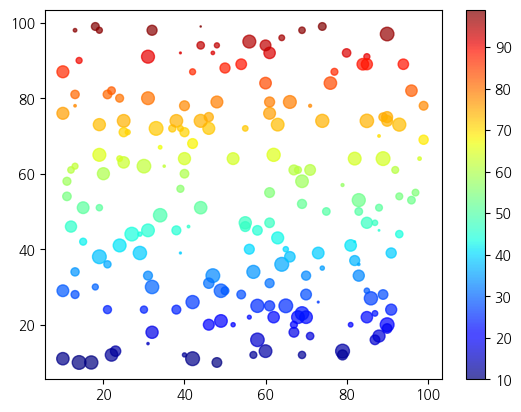

In [ ]:
x = np.random.randint(10, 100, 200)
y = np.random.randint(10, 100, 200)

size = np.random.random(200) * 100

plt.scatter(x, y, s=size, c=y, cmap='jet', alpha = 0.7)
plt.colorbar()
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


[156 180 143 160 158 141 143 145 180 140 145 178 150 158 151 177 186 155
 188 182 141 180 150 140 154 157 178 175 185 187 160 184 158 156 171 158
 187 181 155 181 146 149 181 154 156 184 148 141 142 174 187 142 186 158
 179 155 181 160 167 188 185 187 140 153 193 141 180 187 190 186 152 148
 155 151 170 152 187 184 187 182 142 182 154 161 186 155 149 181 184 146
 147 160 181 148 163 183 162 147 158 155 182 147 164 173 154 177 163 150
 181 177 141 171 186 173 142 142 188 186 165 181]
[50 70 45 64 53 54 40 50 78 54 48 80 48 53 74 76 67 63 69 75 59 73 58 79
 58 54 74 83 82 89 62 82 58 65 83 54 90 70 70 92 49 46 82 66 49 79 56 48
 45 56 84 44 84 55 85 54 85 46 65 79 79 92 59 69 86 61 76 60 85 85 63 47
 55 52 62 47 95 90 74 86 40 60 47 53 80 64 49 78 70 40 40 65 75 43 76 78
 55 54 62 57 80 42 50 49 89 65 81 88 82 58 45 83 81 80 55 45 78 74 56 88]


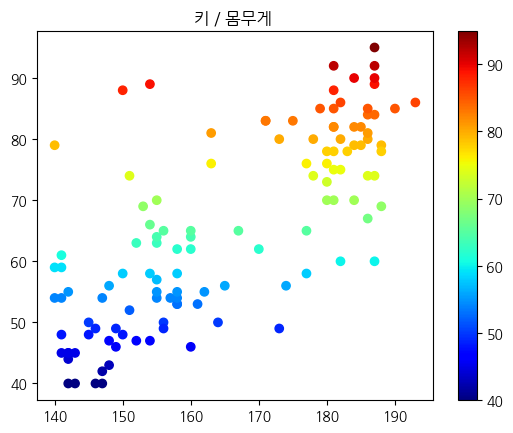

In [ ]:
import csv

f = open('/content/drive/MyDrive/DATA/class.csv', encoding = 'cp949')

data = csv.reader(f)

h = next(data)
w = next(data)

h = np.array(h[2:], dtype = int)
w = np.array(w[2:], dtype = int)

for row in data:
  if '키' in row[1]:
    h = np.concatenate((h, np.array(row[2:], dtype=int)), axis = None)
  if '몸무게' in row[1]:
    w = np.concatenate((w, np.array(row[2:], dtype=int)), axis = None)

print(h)
print(w)
f.close()

plt.title("키 / 몸무게 ")
plt.scatter(h, w, c = w, cmap= 'jet')
plt.colorbar()
plt.show()

In [ ]:
# key : name, age, debut
# value : ["펭수", ..], [10, ..], [2019, ..]
data = {"name" : ["펭수", "뽀로로", "뿡뿡이", "번개맨"],
       "age" : [10, 5, 10, 20],
       "debut" : [2019, 2003, 2000, 2000]}

df = pd.DataFrame(data)


#df["name"]
print(df.index)
print(df.columns)
print(df.values)


RangeIndex(start=0, stop=4, step=1)
Index(['name', 'age', 'debut'], dtype='object')
[['펭수' 10 2019]
 ['뽀로로' 5 2003]
 ['뿡뿡이' 10 2000]
 ['번개맨' 20 2000]]


노래
Dynamite                                  11
아무노래                                       7
다시 여기 바닷가                                  5
VVS (Feat. JUSTHIS) (Prod. GroovyRoom)     5
에잇 (Prod.&Feat. SUGA of BTS)               4
아로하                                        3
시작                                         3
How You Like That                          3
사랑하게 될 줄 알았어                               2
Downtown Baby                              2
METEOR                                     2
DON`T TOUCH ME                             2
처음처럼                                       1
마음을 드려요                                    1
ON                                         1
Name: count, dtype: int64


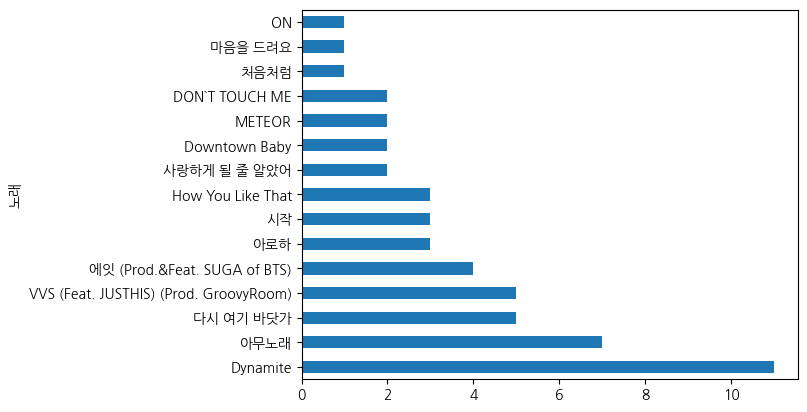

In [3]:
from urllib.request import Request, urlopen
import pandas as pd
import io

url = "https://ko.wikipedia.org/wiki/2020%EB%85%84_%EA%B0%80%EC%98%A8_%EB%94%94%EC%A7%80%ED%84%B8_%EC%B0%A8%ED%8A%B8_1%EC%9C%84_%EB%AA%A9%EB%A1%9D"


req = Request(url, headers={'User-Agent': 'Mozilla/5.0'})
html = urlopen(req).read()

dfs = pd.read_html(io.StringIO(html.decode('utf-8')))

df = dfs[0]
df_cnt = df["노래"].value_counts()
print(df_cnt)
df_cnt.plot(kind="barh")
plt.show()